In [1]:
# suppress tensorflow logging, usually not useful unless you are having problems with tensorflow or accessing gpu
# it seems necessary to have this environment variable set before tensorflow is imported, or else it doesn't take effect
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' 

# imports generally useful throughout the notebook
# usually all imports should happen at the top of a notebook, but in
# these notebooks where the purpose is to show how to use the Keras API
# the relevant imports will happen in the cells where the API is discussed
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

# global settings for notebook output and images
plt.rcParams['figure.figsize'] = (8, 8) # set default figure size, 10in by 8in
np.set_printoptions(precision=4, suppress=True)

E0000 00:00:1748979812.732244   80274 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1748979812.743456   80274 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1748979812.790956   80274 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1748979812.790994   80274 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1748979812.790996   80274 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1748979812.790998   80274 computation_placer.cc:177] computation placer already registered. Please check linka

In [2]:
# import project defined modules / functions used in this notebook
# ensure that the src directory where project modules are found is on
# the PYTHONPATH
import sys
sys.path.append("../src")

# assignment function imports for doctests and github autograding
# these are required for assignment autograding
from nndl import vectorize_samples, plot_history

In [3]:
# if want to restrict to cpu or gpu, configure visible device for rest of notebook to use
#dev = tf.config.list_physical_devices()
#print('Available Devices : ', dev)
#tf.config.set_visible_devices(dev[0], 'CPU')
#tf.config.set_visible_devices(dev[1], 'GPU')

# Chapter 7: Working with Keras: A deep dive

Supporting materials for:

Chollet (2021). *Deep Learning with Python*. 2nd ed. Manning Publications Co.
[Amazon](https://www.amazon.com/Learning-Python-Second-Fran%C3%A7ois-Chollet/dp/1617296864/ref=sr_1_1?crid=32NFM2SBCJVQQ)

After the three practical examples from the previous unit, you should be starting to feel
familiar with how to approach classification and regression problems using neural networks.

You've also experienced some discussion on the central problem of machine learning: **overfitting**.

In this unit, we are going to take a more detailed look at the Keras API.  A better understanding of some
of the details of the different `keras` workflows will help you to better understand the examples
and models we will develop in upcoming chapters.


## 7.1 A Spectrum of Workflows

The design of the Keras API is guided by the principle of progressive disclosure of complexity:
make it easy to get started, yet make it possible to handle high-complexity use cases. 
Simple use cases should be easy and approachable, and arbitrarily advanced workflows should be possible.
As such, there’s not a single “true” way of using Keras. Rather, Keras offers a spectrum
of workflows, from the very simple to the very flexible.

## 7.2 Different Ways to build Keras Models

There are three APis for building models in Keras:

1. The **Sequential model**, the most approachable API—it’s basically a Python list. As
   such, it’s limited to simple stacks of layers.
2. The **Functional API**, which focuses on graph-like model architectures. It represents
   a nice mid-point between usability and flexibility, and as such, it’s the
   most commonly used model-building API.
3. **Model subclassing**, a low-level option where you write everything yourself from
   scratch.

### 7.2.1 The Sequential model

The simplest way to build a Keras model is to use the `Sequential` model.  You should be pretty familiar
with simple sequential models at this point from our previous examples.

In [4]:
from tensorflow import keras
from tensorflow.keras import layers

# a sequent model using the Sequential class,
# layers are actually just passed in as a list of layer objects here
model = keras.Sequential([
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")
])

Its possible to build the same model incrementially via the `add()` method, which is similar to
using `append()` to append items to the end of a Python `List`.

In [5]:
# this would be an equivalent model as the previous
# example, just built incrementally
model = keras.Sequential()
model.add(layers.Dense(64, activation="relu"))
model.add(layers.Dense(10, activation="softmax"))

We have seen that layers only get built when they are called for the first time.  That's
because the layers' weights depends on the shape of their input.  Until the input shape is known, they
can't be created.

As such, the preceeding Sequential model does not have any weights yet until you actually call it on some data or
call its `build()` method.

In [6]:
# internal may have changed from text, we don't see a value error if we access
# this object parameter, just an empty list.
model.weights

[]

But if we explicitly call `build()` and provide the initial input shape (in the following
there are no samples, but we specify 3 features come in as input) then we will have
a set of weights now for the model.

In [7]:
# by providing input shape the model can construct and initialze its weights
model.build(input_shape=(None, 3))

model.weights

I0000 00:00:1748979817.077967   80274 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9706 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:01:00.0, compute capability: 8.6


[<Variable path=sequential_1/dense_2/kernel, shape=(3, 64), dtype=float32, value=[[-0.2572 -0.0605  0.1531 -0.1741 -0.2518 -0.2534  0.0531  0.2919 -0.2282
   -0.0417  0.16   -0.1773  0.2506  0.0632 -0.1472 -0.1549 -0.2199  0.0259
    0.1626 -0.1956  0.1895 -0.2557 -0.0908  0.2459 -0.1587 -0.0817  0.0126
   -0.2011 -0.2634  0.1209 -0.0626 -0.2482  0.2471  0.0156 -0.0836 -0.1012
    0.2012  0.2616  0.2059  0.0167  0.085   0.0546 -0.2009  0.2581 -0.1628
   -0.0998 -0.1492 -0.0328 -0.0451  0.0455 -0.2694 -0.177  -0.0091 -0.1779
   -0.1983 -0.129  -0.0935 -0.261   0.055  -0.1846 -0.2314 -0.2567  0.0801
    0.1928]
  [-0.0692 -0.2069  0.2591  0.0931  0.1976 -0.0848 -0.2107 -0.0078 -0.1903
    0.2035  0.1201 -0.2224  0.0645  0.0266 -0.1973  0.1383 -0.0858  0.2936
    0.0138  0.11    0.0948  0.0612  0.0964  0.2047 -0.1731 -0.0049  0.0726
   -0.1221  0.162   0.0957  0.2361  0.1374 -0.0465 -0.2683 -0.2567  0.0951
    0.1519  0.1789  0.0335  0.2718  0.1125 -0.0184  0.0615  0.0745  0.2967
    0.23

If you look closely, there are 3 sets of 64 tensors and 64 sets of 10 tensors for the two layers
respectively.  All of these weights have been initialized to small random values.  There are also
two sets of biases, one for each layer, initialized to all 0 values.

After a model is built, you can display its contents via the `summary()` method, which
comes in handy for debugging.

In [8]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 906 (3.54 KB)

 Trainable params: 906 (3.54 KB)

 Non-trainable params: 0 (0.00 B)

The names here like "sequential_2" for the model name or "dense_4" for the layer name are auto assigned by
Keras, but you can specify the names to give to layers and models (and everything) to help readabiity.

In [9]:
model = keras.Sequential(name="my_example_model")
model.add(layers.Dense(64, activation="relu", name="my_first_layer"))
model.add(layers.Dense(10, activation="softmax", name="my_last_layer"))
model.build((None, 3))
model.summary()

Model: "my_example_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ my_first_layer (Dense)          │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ my_last_layer (Dense)           │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 906 (3.54 KB)

 Trainable params: 906 (3.54 KB)

 Non-trainable params: 0 (0.00 B)

It can be usefule when building a model incrementally to be able to print a summary of
what the model looks like after each layer is added.  But you can't print a summary until
the model is built!  But you can do this on the fly by declaring the shape of
the model's input in advance using the `Input` class, which you may
see used in some models.

In [10]:
model = keras.Sequential(name="my_example_model")
# use Input to declare the shape of the inputs.  Note that the shape argument
# muste be the shape of each single sample, not the shape of a batch, e.g. just
# a vector with the number of features of input to the first layer
model.add(keras.Input(shape=(3,)))
model.add(layers.Dense(64, activation="relu", name="my_first_layer"))
model.summary()

Model: "my_example_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ my_first_layer (Dense)          │ (None, 64)             │           256 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 256 (1.00 KB)

 Trainable params: 256 (1.00 KB)

 Non-trainable params: 0 (0.00 B)

Now you can use `summary()` to follow how the layer shapes change as you add
more layers.

In [11]:
model.add(layers.Dense(10, activation="softmax", name="my_second_layer"))
model.summary()

Model: "my_example_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ my_first_layer (Dense)          │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ my_second_layer (Dense)         │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 906 (3.54 KB)

 Trainable params: 906 (3.54 KB)

 Non-trainable params: 0 (0.00 B)

This is a pretty common debugging workflow when dealing with layers that
transform their inputs in complex ways, such as convolutional layers.

Also notice the parameter counts given.  This can be useful to judge the size and thus
power of a model.  You should be able to figure out why these two dense layers have
the number of parameter indicated (e.g. for layer 1 we have 3x64 weights and 64
biases).

### 7.2.7 The Functional API

The `Sequential` model is easy to use, but its applicability is extremely limited.  It can only
be used to specify simple models with a single input and a single output, and applying the
tensor transformations one layer after the other in a sequential fashion.

As we will be looking at in the next few units, it's pretty common to encounter
models with multipe inputs, multiple outputs, or a nonlinear network graph.

In such cases you'd build your model using the **Functional API**.  This is what most
Keras models you'll encounter for non-trivial real-world problems will be using.

#### A simple example

Lets start with the stack of two layers we used in the previous example.  To create this
model using the Functional API do the following:

In [12]:
inputs = keras.Input(shape=(3,), name="my_input")
features = layers.Dense(64, activation="relu")(inputs)
outputs = layers.Dense(10, activation="softmax")(features)
model = keras.Model(inputs=inputs, outputs=outputs)

model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ my_input (InputLayer)           │ (None, 3)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 906 (3.54 KB)

 Trainable params: 906 (3.54 KB)

 Non-trainable params: 0 (0.00 B)

We started by declaring an `Input`.  This returns an instance object that we named `inputs`.
The `inputs` object holds information about the `shape` and `dtype` of the data that the
model will process.

In [13]:
# this model will process batches where each sample has shape (3,)
# number of samples per batch is variable, indicate by the None batch size
inputs.shape

(None, 3)

In [14]:
# These batches will have data type float32 (32 bit floating point value)
inputs.dtype

'float32'

We call such an object a **symbolic tensor**. It doesn't contain any actual data, but it
encodes the specifications of the actual tensors of data that the model will see
when you use it.

Next we created a layer. 

```python
features = layers.Dense(64, activation="relu")(inputs)
```

Notice that the actual resulting object was invoked like a function, and we passed the `inputs` symbolic tensor object
to this function.   All Keras layers can be called both on real tensors of data, and on these symbolic tensors.
In the latter case, like above here, they return a new symbolic tensor, with updated shape and
dtype information.

In [15]:
features.shape

(None, 64)

In [16]:
features.dtype

'float32'

After obtaining the final outputs, we instantiated the model by specifying its inputs and outputs in the `Model` constructor:

```python
outputs = layers.Dense(10, activation="softmax")(features)
model = keras.Model(inputs=inputs, outputs=outputs)
```

Here is the summary again of this model.

In [17]:
model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ my_input (InputLayer)           │ (None, 3)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 906 (3.54 KB)

 Trainable params: 906 (3.54 KB)

 Non-trainable params: 0 (0.00 B)

#### Multi-input, multi-output models

Unlike this simple sequential model, most deep learning networks don't look like lists, they
look like graphs. They mave have multiple inputs, multiple outputs, recurrent connections
in the network graph, fan out and fan in parts of the network graph, etc.  Its for
these more complex cases that the Functional API is needed.

In this example we will create a model with three inputs:

1. The title of the ticket (text input)
2. The text body of the ticket (text input)
3. Any tags added by the user (categorical input, assumed here to be one-hot encoded)

We can encode the text inputs as arrays of ones and zeros of size `vocaublary_size`.


And the model will have two outputs
1. The priority score of the ticket, a scalar between 0 and 1 (`sigmoid` output)
2. The department that should handle the ticket (a `softmax` over the set of departments).

You can build this multi-input / multi-output model in a few 10's of lines of Functional Keras
API code:

In [18]:
# sizes of the one-hot / multi-hot encodings being used
vocabulary_size = 10000
num_tags = 100
num_departments = 4

# define the 3 model inputs
title = keras.Input(shape=(vocabulary_size,), name="title")
text_body = keras.Input(shape=(vocabulary_size,), name="text_body")
tags = keras.Input(shape=(num_tags,), name="tags")

# combine input features into a single tensor `features` by concatenating them
features = layers.Concatenate(name="my_input_concatenation_layer")([title, text_body, tags])

# apply an intermediate layer to recombine input features into richer representations
# on first glance you may think we have lost the first features and overwritten it here,
# but there are 2 layeres, the first features was passed in as a parameter to the constructor here,
# but after this line only the second features layer has a local variable we can access
features = layers.Dense(64, activation="relu", name="my_dense_layer")(features)

# define the 2 model outputs, notice that these outputs both recieve
# inputs from the last features layer, we have split the graph into two output
# paths
priority = layers.Dense(1, activation="sigmoid", name="priority")(features)
department = layers.Dense(num_departments, activation="softmax", name="department")(features)

# create the model by specifying its 3 inputs and 2 outputs
model = keras.Model(inputs=[title, text_body, tags],
                    outputs=[priority, department],
                    name="my_3_input_2_output_model")

model.summary()

Model: "my_3_input_2_output_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ title (InputLayer)  │ (None, 10000)     │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_body           │ (None, 10000)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tags (InputLayer)   │ (None, 100)       │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ my_input_concatena… │ (None, 20100)     │          0 │ title[0][0],      │
│ (Concatenate)       │                   │            │ text_body[0][0],  │
│                     │                   │            │ tags[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ my_dense_layer      │ (None, 64)        │  1,286,464 │ my_input_concate… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ priority (Dense)    │ (None, 1)         │         65 │ my_dense_layer[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ department (Dense)  │ (None, 4)         │        260 │ my_dense_layer[0… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,286,789 (4.91 MB)

 Trainable params: 1,286,789 (4.91 MB)

 Non-trainable params: 0 (0.00 B)

Notice the number of trainable parameters in this relatively small 3 input, 2 output with 1 dense layer network!

The Functional API is a simple, LEGO-like, yet very flexible way to define arbitrary graphs of layers like these.

#### Training a multi-input, multi-output model

You can train this model in much the same way as you would train a `Sequential` model, by calling `fit()` with lists of inputs
and target output data.  These lists of data should be in the same order as the inputs you passed to the `Model` constructor.

In [19]:
# some dummy random input data and target data, so model will train and fit, but predictions are meaningless
num_samples = 1280

# dummy input data
title_data = np.random.randint(0, 2, size=(num_samples, vocabulary_size))
text_body_data = np.random.randint(0, 2, size=(num_samples, vocabulary_size))
tags_data = np.random.randint(0, 2, size=(num_samples, num_tags))

# dummy target data
priority_data = np.random.random(size=(num_samples, 1))
department_data = np.random.randint(0, 2, size=(num_samples, num_departments))

In [20]:
# compile, fit and evaluate the model

# notice we supply 2 loss functions and 2 (lists of) metrics.
# these need to be in same order as outputs, so we use MSE for the priority loss
# and we use categorical crossentropy for the department output
model.compile(optimizer="rmsprop",
              loss=["mean_squared_error", "categorical_crossentropy"],
              metrics=[["mean_absolute_error"], ["accuracy"]])

# fit takes the input and target data.  So we have a list of 3 inputs
# and a list of 2 outputs, again the inputs and outputs need to be in
# the same order as defined in the model.
model.fit([title_data, text_body_data, tags_data],
          [priority_data, department_data],
          epochs=1)

model.evaluate([title_data, text_body_data, tags_data],
               [priority_data, department_data])

priority_preds, department_preds = model.predict([title_data, text_body_data, tags_data])

I0000 00:00:1748979820.199938   80380 service.cc:152] XLA service 0x79c174003da0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1748979820.199995   80380 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 3060, Compute Capability 8.6
I0000 00:00:1748979820.306656   80380 cuda_dnn.cc:529] Loaded cuDNN version 90300


32/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - department_accuracy: 0.3078 - department_loss: 32.6731 - loss: 32.9669 - priority_loss: 0.2938 - priority_mean_absolute_error: 0.4632

I0000 00:00:1748979821.335803   80380 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - department_accuracy: 0.3108 - department_loss: 30.6577 - loss: 30.9576 - priority_loss: 0.2999 - priority_mean_absolute_error: 0.4693
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - department_accuracy: 0.5245 - department_loss: 5.0351 - loss: 5.3579 - priority_loss: 0.3228 - priority_mean_absolute_error: 0.4937
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


As mentioned in the comments, because of how we defined the input and output layers, you have to rely on
providing the input data, loss functions and metrics in the same order.

If you don't want to rely on input order, you can also leverage the names given to the `Input` objects
and the output layers, and pass data via dictionaries instead of lists.

In [21]:
# same as before, but pass in dictionaries and use the Input / layer names as keys
model.compile(optimizer="rmsprop",
              loss={"priority": "mean_squared_error",
                    "department": "categorical_crossentropy"},
              metrics={"priority": ["mean_absolute_error"], 
                       "department": ["accuracy"]})

model.fit({"title": title_data, 
           "text_body": text_body_data,
           "tags": tags_data},
          {"priority": priority_data, 
           "department": department_data},
          epochs=1)

model.evaluate({"title": title_data, 
                "text_body": text_body_data, 
                "tags": tags_data},
               {"priority": priority_data, 
                "department": department_data})

priority_preds, department_preds = model.predict({"title": title_data, 
                                                  "text_body": text_body_data,
                                                  "tags": tags_data})

40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - department_accuracy: 0.3092 - department_loss: 25.7192 - loss: 26.0407 - priority_loss: 0.3216 - priority_mean_absolute_error: 0.4905
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - department_accuracy: 0.1114 - department_loss: 8.1264 - loss: 8.4491 - priority_loss: 0.3228 - priority_mean_absolute_error: 0.4937
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


#### The power of the Functional API: Access to layer connectivity

A Functional model is an explicit graph data structure.  This enables two important use cases: model visualization
and feature extraction.

First let's visualize the connectivity of the model we just defined (the **topology** of the model).
You can plot a Functional model as a graph with the `plot_model()` utility.

**Note:** you will need the `pydot` python libtary for `plot_model()` to work.  I have added this
to the `environment.yml` file for this project, but if you don't have it, use the `pip install pydot` as 
suggested, or if you are using conda package installer (as recommended for this class), try `conda install pydot`

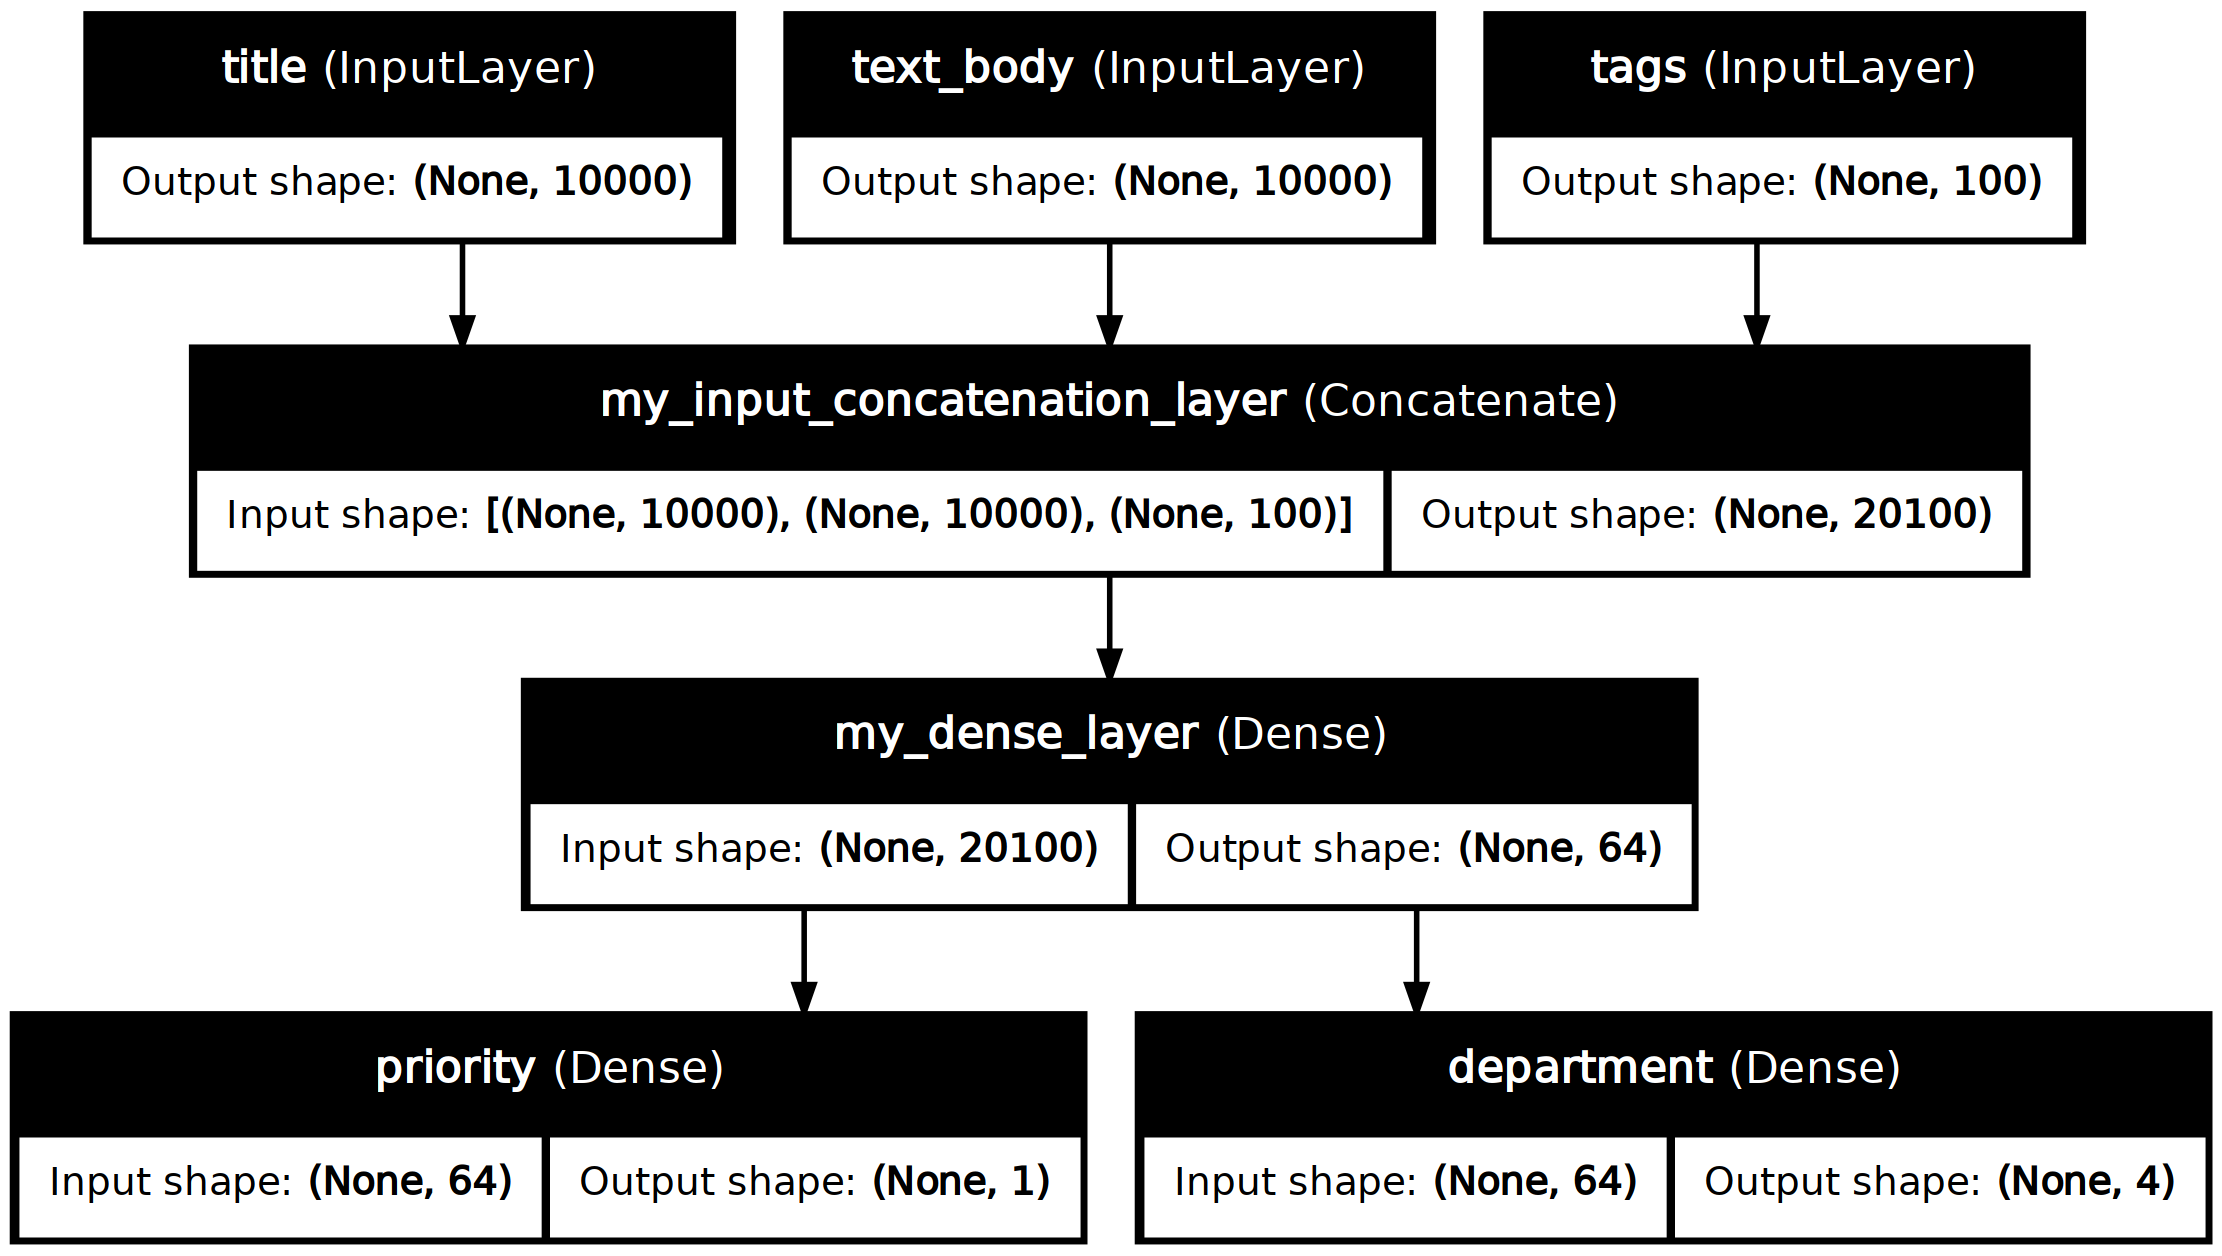

In [29]:
# invoke plot_model, this will regenerate the figure .png file in the specified location, and we
# will display this figure in the next markdown cell
# NOTE: you don't get layer names in plot by default anymore, need to enable them
keras.utils.plot_model(model,
    to_file="../figures/ticket_classifier_with_shape_info.png",
    show_shapes=True,
    show_layer_names=True)

![3 input, two output Functionaly Created Model](../figures/ticket_classifier_with_shape_info.png)

The "None" in the tensor shapes represents the batch size: this model allows batches of any size.

Access to layer connectivity also means you can inspect and reuse individual nodes in the graph.  The
`model.layers` model property provides the list of layers that make up the model, and for each layer
you can query `layer.input` and `layer.output`

In [23]:
model.layers

[<InputLayer name=title, built=True>,
 <InputLayer name=text_body, built=True>,
 <InputLayer name=tags, built=True>,
 <Concatenate name=my_input_concatenation_layer, built=True>,
 <Dense name=my_dense_layer, built=True>,
 <Dense name=priority, built=True>,
 <Dense name=department, built=True>]

In [24]:
# the third layer from 0 indexing is the Concatenate layer
model.layers[3].input

[<KerasTensor shape=(None, 10000), dtype=float32, sparse=False, ragged=False, name=title>,
 <KerasTensor shape=(None, 10000), dtype=float32, sparse=False, ragged=False, name=text_body>,
 <KerasTensor shape=(None, 100), dtype=float32, sparse=False, ragged=False, name=tags>]

In [25]:
model.layers[3].output

<KerasTensor shape=(None, 20100), dtype=float32, sparse=False, ragged=False, name=keras_tensor_12>

This enables you to do **feature extraction**, creating models that reuse intermediate features
from another model.

Let's say you want to add another output to the previous model, to estimate how long a given issue
ticket will take to resolve (a difficulty rating).  We can make this a categorical output over
three levels of dificulty "quick", "medium" and "difficult".  

You don't have to retrain a model from scratch.  You can start from the intermediate features of your previous model sinc you have access to
them as follows.

In [26]:
# layers[4] is our intermediate Dense layer, before the initial 2 output layers we had
features = model.layers[4].output

# create a new output layer, and connect it to the features Dense layer to get its inputs
difficulty = layers.Dense(3, activation="softmax", name="difficulty")(features)

# a new separate model now with difficulty output, but reusing all other
# layers from first model
new_model = keras.Model(inputs=[title, text_body, tags],
                        outputs=[priority, department, difficulty])

Here is what the plot of the new model now looks like.

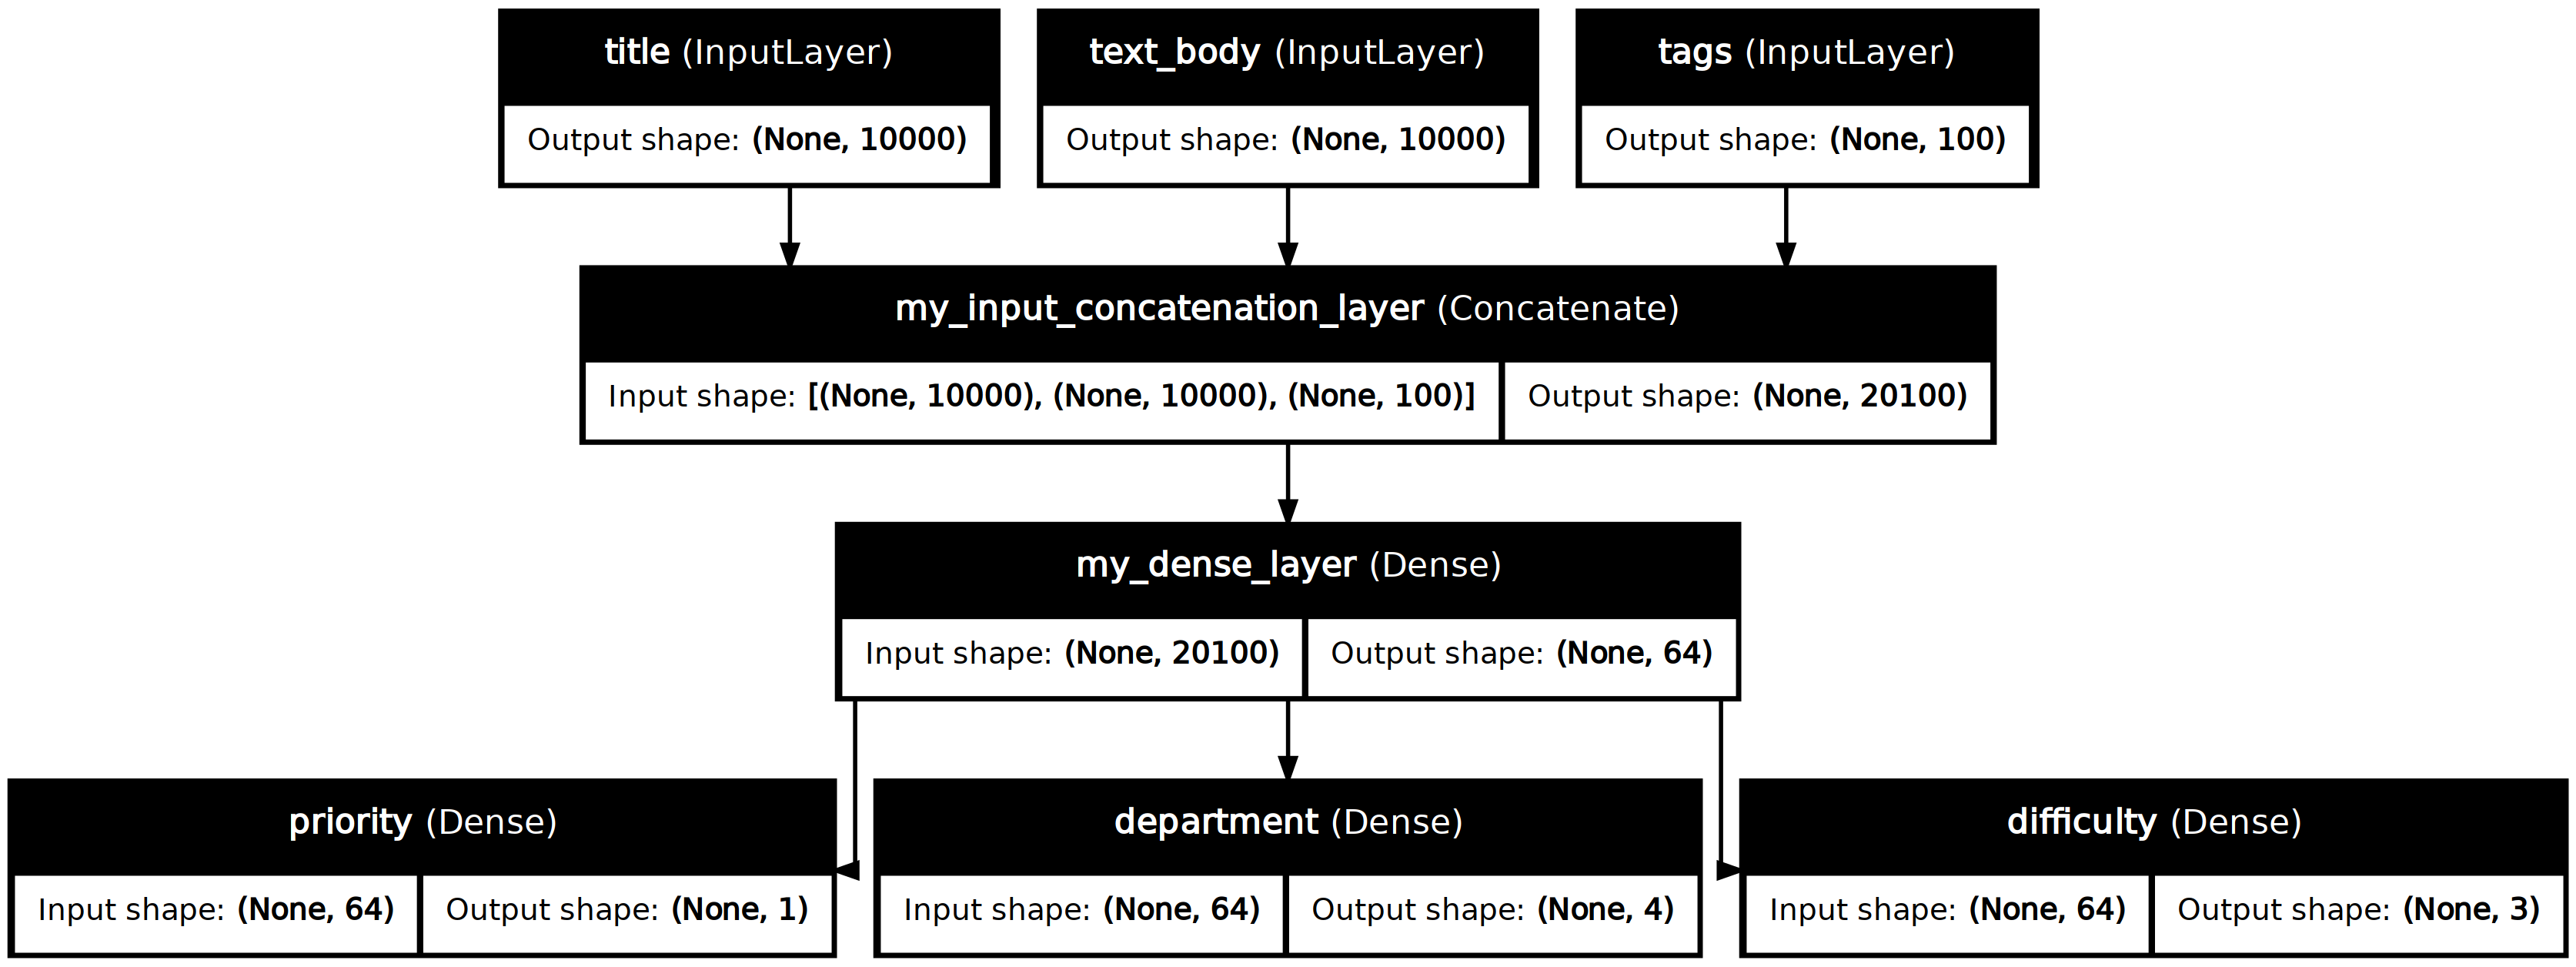

In [30]:
keras.utils.plot_model(new_model, to_file="../figures/updated_ticket_classifier.png", show_shapes=True, show_layer_names=True)

### 7.2.3 Subclassing the Model Class

The last model-building pattern you should know about is the most advanced one: `Model` subclassing.

We had a quick example of subclassing the `Layer` class previously when we first looked at the core Keras API.
Subclassing a `Model` requires you to:
- In the `__init__()` method, define the layers the model will use.
- In the `call()` method, define the forward pass of the model, reusing the layers
  previously created.
- Instantiate your subclass, and call it on data to create its weights.

#### Rewriting our previous example as a subclassed model

Let's look at a simple example of subclassing a `Model`.  We reimplement the customer
support ticket managment model using a `Model` subclass.

In [31]:
class CustomerTicketModel(keras.Model):

    def __init__(self, num_departments):
        # don't forget to call the super() classes constructor
        super().__init__()
        # define sublayers in the constructor
        self.concat_layer = layers.Concatenate()
        self.mixing_layer = layers.Dense(64, activation="relu")
        self.priority_scorer = layers.Dense(1, activation="sigmoid")
        self.department_classifier = layers.Dense(num_departments, activation="softmax")

    # define the forward pass in the call() method
    def call(self, inputs):
        title = inputs["title"]
        text_body = inputs["text_body"]
        tags = inputs["tags"]
        features = self.concat_layer([title, text_body, tags])
        features = self.mixing_layer(features)
        priority = self.priority_scorer(features)
        department = self.department_classifier(features)
        return priority, department

Once you've defined the model, you can insantiate it.  Note that it will only create its weights
the first time you call it on some data.

In [34]:
model = CustomerTicketModel(num_departments=4)

priority, department = model(
    {"title": title_data, "text_body": text_body_data, "tags": tags_data})

model.summary()

Model: "customer_ticket_model_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ concatenate_1 (Concatenate)     │ (1280, 20100)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (1280, 64)             │     1,286,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (1280, 1)              │            65 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (1280, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,286,789 (4.91 MB)

 Trainable params: 1,286,789 (4.91 MB)

 Non-trainable params: 0 (0.00 B)